<a href="https://colab.research.google.com/github/OscarLMAR/-Global-Air-Pollution-Data/blob/main/S20_Evidencia_de_Aprendizaje_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **S20 - Evidencia de Aprendizaje 1 y 2**

# Oscar Luis Marquez Arrieta

Institución Universitaria Digital de Antioquia
Proyecto Integrado lll - Analitica de Dtos
Andres Felipe Palacio

2026


In [24]:
!pip install ydata-profiling

In [25]:

!pip install kagglehub[pandas-datasets]>=0.3.8

In [27]:
#IMPORTACION DE LIBRERIAS
import kagglehub
import os
import zipfile
import pandas as pd
from ydata_profiling import ProfileReport

In [28]:
#CARGA DEL DATASET
!pip install kaggle

# **Descargamos, extraemos y leemos el dataset de Kaggle**

In [30]:
def download_dataset_zip(url = ""):
        print("Descargando dataset desde Kaggle...")
        dataset_path = kagglehub.dataset_download(url)
        print("Ruta al dataset:", dataset_path)
        return dataset_path

def extract_zip_files(dataset_path):
        zip_files = [f for f in os.listdir(dataset_path) if f.endswith('.zip')]
        if zip_files:
            zip_file = os.path.join(dataset_path, zip_files[0])
            extract_dir = os.path.join(dataset_path, "extracted")
            os.makedirs(extract_dir, exist_ok=True)
            print(f"Extrayendo {zip_file} en {extract_dir}...")
            with zipfile.ZipFile(zip_file, "r") as z:
                z.extractall(extract_dir)
            return extract_dir
        else:
            # Si no se encuentra un ZIP, se verifica si existen archivos CSV en la ruta
            csv_files = [f for f in os.listdir(dataset_path) if f.endswith('.csv')]
            if csv_files:
                print("No se encontró archivo ZIP pero se detectaron archivos CSV; se asume que el dataset ya se encuentra extraído.")
                return dataset_path
            else:
                raise FileNotFoundError("No se encontró ningún archivo .zip ni archivos .csv en la ruta del dataset")

def create_csv(csv_dir):
        #os.makedirs('src/static/csv', exist_ok=True)
        csv_files = [f for f in os.listdir(csv_dir) if f.endswith('.csv')]
        if not csv_files:
            raise FileNotFoundError("No se encontraron archivos CSV en el directorio extraído")

        for file in csv_files:
            file_path = os.path.join(csv_dir, file)
            print(f"Leyendo {file_path}...")
            try:
                df = pd.read_csv(file_path, encoding="latin1")
            except Exception as e:
                print(f"Error al leer {file}: {e}")
                continue
            print(f"Creando/actualizando ")
        print("cvs creado correctamente en ")
        return df



# **Descargamos Dataset**

In [31]:
df = pd.DataFrame()
dataset = download_dataset_zip("sazidthe1/global-air-pollution-data")
csv_dir =extract_zip_files(dataset)
df = create_csv(csv_dir)


Descargando dataset desde Kaggle...


100%|██████████| 371k/371k [00:00<00:00, 52.5MB/s]

Extracting files...
Ruta al dataset: /root/.cache/kagglehub/datasets/sazidthe1/global-air-pollution-data/versions/3
No se encontró archivo ZIP pero se detectaron archivos CSV; se asume que el dataset ya se encuentra extraído.
Leyendo /root/.cache/kagglehub/datasets/sazidthe1/global-air-pollution-data/versions/3/global_air_pollution_data.csv...
Creando/actualizando 
cvs creado correctamente en 


In [49]:
df.head(10)

,ï»¿country_name,city_name,aqi_value,aqi_category,co_aqi_value\t,co_aqi_category,ozone_aqi_value,ozone_aqi_category,no2_aqi_value,no2_aqi_category,pm2.5_aqi_value,pm2.5_aqi_category
0,Russian Federation,Praskoveya,51,Moderate,1,Good,36,Good,0,Good,51,Moderate
1,Brazil,Presidente Dutra,41,Good,1,Good,5,Good,1,Good,41,Good
2,Italy,Priolo Gargallo,66,Moderate,1,Good,39,Good,2,Good,66,Moderate
3,Poland,Przasnysz,34,Good,1,Good,34,Good,0,Good,20,Good
4,France,Punaauia,22,Good,0,Good,22,Good,0,Good,6,Good
5,United States of America,Punta Gorda,54,Moderate,1,Good,14,Good,11,Good,54,Moderate
6,Germany,Puttlingen,62,Moderate,1,Good,35,Good,3,Good,62,Moderate
7,Belgium,Puurs,64,Moderate,1,Good,29,Good,7,Good,64,Moderate
8,Russian Federation,Pyatigorsk,54,Moderate,1,Good,41,Good,1,Good,54,Moderate
9,Egypt,Qalyub,142,Unhealthy for Sensitive Groups,3,Good,89,Moderate,9,Good,142,Unhealthy for Sensitive Groups


In [33]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23463 entries, 0 to 23462
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   ï»¿country_name     23036 non-null  object
 1   city_name           23462 non-null  object
 2   aqi_value           23463 non-null  int64 
 3   aqi_category        23463 non-null  object
 4   co_aqi_value	       23463 non-null  int64 
 5   co_aqi_category     23463 non-null  object
 6   ozone_aqi_value     23463 non-null  int64 
 7   ozone_aqi_category  23463 non-null  object
 8   no2_aqi_value       23463 non-null  int64 
 9   no2_aqi_category    23463 non-null  object
 10  pm2.5_aqi_value     23463 non-null  int64 
 11  pm2.5_aqi_category  23463 non-null  object
dtypes: int64(5), object(7)
memory usage: 2.1+ MB


,aqi_value,co_aqi_value\t,ozone_aqi_value,no2_aqi_value,pm2.5_aqi_value
count,23463.000000,23463.000000,23463.000000,23463.000000,23463.000000
mean,72.010868,1.368367,35.193709,3.063334,68.519755
std,56.055220,1.832064,28.098723,5.254108,54.796443
min,6.000000,0.000000,0.000000,0.000000,0.000000
25%,39.000000,1.000000,21.000000,0.000000,35.000000
50%,55.000000,1.000000,31.000000,1.000000,54.000000
75%,79.000000,1.000000,40.000000,4.000000,79.000000
max,500.000000,133.000000,235.000000,91.000000,500.000000


In [34]:
# Contar duplicados
df.duplicated().sum()

# Eliminar duplicados (opcional)
df = df.drop_duplicates()

In [35]:
# Ver valores nulos por columna
df.isnull().sum()

# Porcentaje de nulos
(df.isnull().sum() / len(df)) * 100

,0
ï»¿country_name,1.819887
city_name,0.004262
aqi_value,0.000000
aqi_category,0.000000
co_aqi_value\t,0.000000
co_aqi_category,0.000000
ozone_aqi_value,0.000000
ozone_aqi_category,0.000000
no2_aqi_value,0.000000
no2_aqi_category,0.000000


In [36]:
df.dtypes

,0
ï»¿country_name,object
city_name,object
aqi_value,int64
aqi_category,object
co_aqi_value\t,int64
co_aqi_category,object
ozone_aqi_value,int64
ozone_aqi_category,object
no2_aqi_value,int64
no2_aqi_category,object


In [37]:
profile = ProfileReport(df, title="Reporte Calidad del Aire", explorative=True)

profile.to_file("reporte.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 12/12 [00:01<00:00, 10.94it/s]
/usr/local/lib/python3.12/dist-packages/ydata_profiling/visualisation/utils.py:73: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.savefig(
/usr/local/lib/python3.12/dist-packages/ydata_profiling/visualisation/utils.py:73: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.savefig(
/usr/local/lib/python3.12/dist-packages/ydata_profiling/visualisation/utils.py:73: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.savefig(
/usr/local/lib/python3.12/dist-packages/ydata_profiling/visualisation/utils.py:73: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.savefig(
/usr/local/lib/python3.12/dist-packages/ydata_profiling/visualisation/utils.py:73: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.savefig(
/usr/local/lib/python3.12/dist-packages/ydata_profiling/visualisation/utils.py:73: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.savefig(
/usr/loca

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/ydata_profiling/visualisation/utils.py:73: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.savefig(


Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

# **S25 - Evidencia de Aprendizaje 2**

# **Objetivo:**

Llevar a cabo un proceso de limpieza y transformación del conjunto de datos para asegurar su calidad y adecuación para el análisis.

# **Descripción y necesidad de limpieza.**

# **Duplicados:** Indica si existen duplicados en el dataset y en qué columnas podrían estar.

In [38]:
df.duplicated().sum()

np.int64(0)

Validando en el analisis que hemos comenzado, pudimos evidenciar que no existe ningun dato duplicado en nuestro dataset, entonces, continuaremos haciendo el analisis en nuestro ya mencionado dataset.

# **Valores Nulos:** Identifica las columnas con valores nulos, la proporción de datos faltantes y la posible relevancia de estos para el análisis.

In [39]:
df.isnull().sum()

,0
ï»¿country_name,427
city_name,1
aqi_value,0
aqi_category,0
co_aqi_value\t,0
co_aqi_category,0
ozone_aqi_value,0
ozone_aqi_category,0
no2_aqi_value,0
no2_aqi_category,0


En este analisis, se detectaron valores nulos en dos columnas, principalmente en la columna country_name fueron 427 registros faltantes y en city_name solo se encontro un registro nulo, en esta es necesario mas adelante, hacer una limpieza de datos.

# **Inconsistencias en Valores:** Revisa si existen valores inconsistentes o errores tipográficos en columnas clave, como nombres de ciudades, categorías, o fechas.

In [52]:
df['city_name'].value_counts(2)

,proportion
city_name,
Marang,0.000043
Praskoveya,0.000043
Presidente Dutra,0.000043
Priolo Gargallo,0.000043
Przasnysz,0.000043
...,...
Qinzhou,0.000043
Qalyub,0.000043
Pyatigorsk,0.000043


In [54]:
df['ï»¿country_name'].value_counts(2)

,proportion
ï»¿country_name,
United States of America,0.124674
India,0.108005
Brazil,0.067807
Germany,0.058387
Russian Federation,0.053872
...,...
Bahrain,0.000043
Seychelles,0.000043
State of Palestine,0.000043


Podriamos decir que no existes errores tipograficos en nuestro dataset, pude revisar dos variables claves y no evidencie errores, por lo que con estas variables por el momento no es necesario hacerles limpieza de datos.

# **Tipos de Datos:** Identifica columnas cuyo tipo de dato no es adecuado y describe qué tipo de corrección es necesario realizar.

In [57]:
df.dtypes

,0
ï»¿country_name,object
city_name,object
aqi_value,int64
aqi_category,object
co_aqi_value\t,int64
co_aqi_category,object
ozone_aqi_value,int64
ozone_aqi_category,object
no2_aqi_value,int64
no2_aqi_category,object


Podemos observar, que el datset presenta tipos de datos adecuados para las columnas que se estan visualizando, lo que por el momento en este caso, no le hariamos ningun cambio o limpieza.

# **Valores Atípicos:** Describe variables en las que los valores atípicos pueden ser problemáticos y considera si estos necesitan un tratamiento especial.

In [58]:
df.describe()

,aqi_value,co_aqi_value\t,ozone_aqi_value,no2_aqi_value,pm2.5_aqi_value
count,23463.000000,23463.000000,23463.000000,23463.000000,23463.000000
mean,72.010868,1.368367,35.193709,3.063334,68.519755
std,56.055220,1.832064,28.098723,5.254108,54.796443
min,6.000000,0.000000,0.000000,0.000000,0.000000
25%,39.000000,1.000000,21.000000,0.000000,35.000000
50%,55.000000,1.000000,31.000000,1.000000,54.000000
75%,79.000000,1.000000,40.000000,4.000000,79.000000
max,500.000000,133.000000,235.000000,91.000000,500.000000


En el análisis de los datos se identificaron posibles valores atípicos en las variables relacionadas con la calidad del aire, especialmente en **aqi_value** y **pm2.5_aqi_value**. Aunque la mayoría de los registros se concentra en valores moderados, existen algunos casos con valores extremadamente altos, alcanzando hasta 500 puntos de AQI.

Estos valores pueden representar episodios reales de contaminación severa, por lo que no deben considerarse automáticamente como errores. Sin embargo, también podrían influir en los resultados estadísticos, afectando promedios y visualizaciones.

# **Nivel de Granularidad:** Evalúa si el dataset tiene un nivel de detalle mayor al requerido (por ejemplo, datos diarios cuando solo se necesitan datos mensuales). Considera si es necesario agregar datos para lograr la granularidad deseada.

In [60]:
df.groupby("ï»¿country_name")["aqi_value"].mean()

,aqi_value
ï»¿country_name,
Afghanistan,95.959184
Albania,68.250000
Algeria,88.166667
Andorra,29.333333
Angola,83.925926
...,...
Venezuela (Bolivarian Republic of),77.722222
Viet Nam,87.050000
Yemen,144.571429


En este utlimo, podriamos hacer una granuralidad general, que podria ser, promedio por pais, ahi podemos mas adelante organizar y ver como nos queda.

# **Limpieza y Transformación de Datos**

### **Eliminacion de duplicados**

Anterioremente vimos que no se encomntro ningun duplicado, pero vamos a realizar una limpieza por si se nos pasa alguno.

In [61]:
df = df.drop_duplicates()

# **Tratamiento de Valores Nulos**

Durante el análisis se identificaron valores nulos principalmente en la columna country_name, mientras que city_name presentó solo un valor faltante.

In [63]:
df["ï»¿country_name"] = df["ï»¿country_name"].fillna(df["ï»¿country_name"].mode()[0])

In [64]:
df["city_name"] = df["city_name"].fillna(df["city_name"].mode()[0])

se optó por completar los valores faltantes utilizando la moda (valor más frecuente).

# **Detección y Tratamiento de Valores Atípicos**

Las variables aqi_value y pm2.5_aqi_value presentaron valores máximos elevados, alcanzando hasta 500 puntos de AQI. Estos valores podrían representar episodios reales de contaminación extrema y no necesariamente errores de registro.

Por esta razón, no se eliminaron automáticamente los valores atípicos.

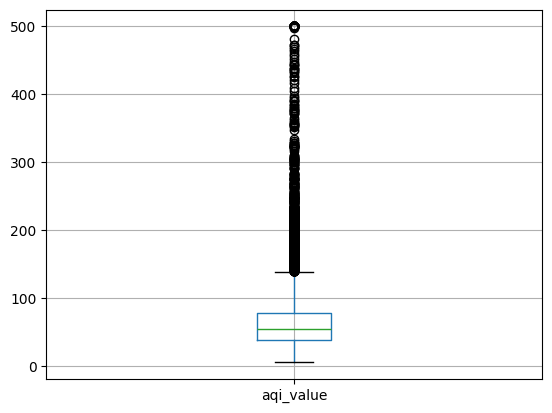

In [65]:
import matplotlib.pyplot as plt

df.boxplot(column="aqi_value")
plt.show()


# **Correcciones de Valores con replace(), map() y zip()**

Se realizaron correcciones básicas para estandarizar nombres y categorías en el dataset.

In [68]:
#utilizando replace()

df["ï»¿country_name"] = df["ï»¿country_name"].replace({
    "Viet Nam": "Vietnam"
})

In [73]:
df[df["ï»¿country_name"] == "Vietnam"]

,ï»¿country_name,city_name,aqi_value,aqi_category,co_aqi_value\t,co_aqi_category,ozone_aqi_value,ozone_aqi_category,no2_aqi_value,no2_aqi_category,pm2.5_aqi_value,pm2.5_aqi_category
86,Vietnam,Tay Ninh,45,Good,0,Good,18,Good,1,Good,45,Good
94,Vietnam,Thai Nguyen,150,Unhealthy,3,Good,150,Unhealthy,1,Good,105,Unhealthy for Sensitive Groups
131,Vietnam,Tuyen Quang,167,Unhealthy,4,Good,167,Unhealthy,1,Good,107,Unhealthy for Sensitive Groups
301,Vietnam,Chau Doc,57,Moderate,1,Good,32,Good,0,Good,57,Moderate
1544,Vietnam,Cao Bang,47,Good,1,Good,32,Good,0,Good,47,Good
1785,Vietnam,Bac Giang,179,Unhealthy,10,Good,8,Good,22,Good,179,Unhealthy
1798,Vietnam,Quang Ngai,62,Moderate,1,Good,32,Good,0,Good,62,Moderate
2130,Vietnam,Tuy Hoa,51,Moderate,1,Good,26,Good,0,Good,51,Moderate
2201,Vietnam,Ben Tre,77,Moderate,1,Good,27,Good,2,Good,77,Moderate
2666,Vietnam,Hanoi,181,Unhealthy,4,Good,181,Unhealthy,1,Good,145,Unhealthy for Sensitive Groups


In [74]:
#Utlilizando map()

categorias = {
    "Good": "Buena",
    "Moderate": "Moderada",
    "Poor": "Mala"
}

df["aqi_category_es"] = df["aqi_category"].map(categorias)

In [75]:
df.head()

,ï»¿country_name,city_name,aqi_value,aqi_category,co_aqi_value\t,co_aqi_category,ozone_aqi_value,ozone_aqi_category,no2_aqi_value,no2_aqi_category,pm2.5_aqi_value,pm2.5_aqi_category,aqi_category_es
0,Russian Federation,Praskoveya,51,Moderate,1,Good,36,Good,0,Good,51,Moderate,Moderada
1,Brazil,Presidente Dutra,41,Good,1,Good,5,Good,1,Good,41,Good,Buena
2,Italy,Priolo Gargallo,66,Moderate,1,Good,39,Good,2,Good,66,Moderate,Moderada
3,Poland,Przasnysz,34,Good,1,Good,34,Good,0,Good,20,Good,Buena
4,France,Punaauia,22,Good,0,Good,22,Good,0,Good,6,Good,Buena


In [77]:
df["aqi_category_es"]

,aqi_category_es
0,Moderada
1,Buena
2,Moderada
3,Buena
4,Buena
...,...
23458,NaN
23459,Buena
23460,Buena
23461,Moderada


# **Agregación de Datos**

Se realizó una agregación de datos calculando el promedio del índice de calidad del aire (AQI) por país. Esto permitió obtener una visión más general de los niveles de contaminación en cada país y facilitar comparaciones entre regiones.

In [79]:
promedio_pais = df.groupby("ï»¿country_name")["aqi_value"].mean()

print(promedio_pais)

ï»¿country_name
Afghanistan                            95.959184
Albania                                68.250000
Algeria                                88.166667
Andorra                                29.333333
Angola                                 83.925926
                                         ...    
Venezuela (Bolivarian Republic of)     77.722222
Vietnam                                87.050000
Yemen                                 144.571429
Zambia                                 40.666667
Zimbabwe                               43.740741
Name: aqi_value, Length: 175, dtype: float64


In [80]:
promedio_pais = df.groupby("ï»¿country_name", as_index=False)["aqi_value"].mean()

print(promedio_pais)

                        ï»¿country_name   aqi_value
0                           Afghanistan   95.959184
1                               Albania   68.250000
2                               Algeria   88.166667
3                               Andorra   29.333333
4                                Angola   83.925926
..                                  ...         ...
170  Venezuela (Bolivarian Republic of)   77.722222
171                             Vietnam   87.050000
172                               Yemen  144.571429
173                              Zambia   40.666667
174                            Zimbabwe   43.740741

[175 rows x 2 columns]


In [81]:
#país más contaminado al menos contaminado
promedio_pais = (
    df.groupby("ï»¿country_name", as_index=False)["aqi_value"]
    .mean()
    .sort_values(by="aqi_value", ascending=False)
)

print(promedio_pais)

                      ï»¿country_name   aqi_value
126                 Republic of Korea  421.000000
11                            Bahrain  188.000000
98                         Mauritania  179.000000
116                          Pakistan  178.788274
163              United Arab Emirates  163.666667
..                                ...         ...
19   Bolivia (Plurinational State of)   23.787879
68                            Iceland   23.000000
95                           Maldives   19.000000
142                   Solomon Islands   18.000000
117                             Palau   16.000000

[175 rows x 2 columns]


# **Validación**


Después del proceso de limpieza, el dataset presenta una mejora en la calidad de la información. Los valores nulos identificados en las columnas country_name y city_name fueron tratados mediante imputación utilizando la moda, evitando la pérdida innecesaria de registros.

Además, se verificó que no existieran filas duplicadas que pudieran afectar el análisis. Durante el proceso de agregación con groupby(), no se eliminaron datos relevantes, ya que únicamente se resumió la información para facilitar el análisis por país.

Esto garantiza que el dataset conserve suficiente información para realizar análisis confiables sobre la calidad del aire.

# **las Variables**

Las variables incluidas en el dataset son relevantes para responder a los objetivos del análisis relacionados con la contaminación y la calidad del aire.

Variables como:

aqi_value
pm2.5_aqi_value
ozone_aqi_value
no2_aqi_value
country_name
city_name
categorías AQI

permiten evaluar niveles de contaminación, comparar ciudades y países, e identificar patrones de calidad del aire.

Por lo tanto, el dataset contiene información suficiente y pertinente para desarrollar análisis descriptivos y comparativos.

# **Granularidad Adecuada**

El nivel de detalle original del dataset se encuentra a nivel de ciudad, lo cual proporciona información específica y útil para análisis detallados.

Posteriormente, se realizaron agregaciones por país utilizando promedios del índice AQI para obtener una visión más general y facilitar comparaciones globales entre países.

Esta combinación de granularidad por ciudad y agregación por país permite obtener insights tanto específicos como generales, dependiendo del objetivo del análisis.

# **Conclusión**

Tras el proceso de limpieza y transformación, el dataset se considera adecuado para continuar con el análisis de calidad del aire. Los problemas de valores nulos, inconsistencias y tipos de datos fueron tratados correctamente, y la información conservada permite responder a los objetivos planteados inicialmente.